# Model pipeline - Regression  

This notebook fits and evaluates an XGBoost regressor for predicting the magnitude of biodiversity anomalies based on weather features  

Note: Time series data - cannot use random train-test split (that would leak future information)

---
### Load packages and data

In [1]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

from sklearn import set_config
set_config(transform_output='pandas')

In [2]:
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

In [4]:
full_df.columns

Index(['state', 'monthyear', 'year', 'month', 'mean_temp', 'max_temp',
       'total_precip', 'n_hot_days', 'heavy_rain_days', 'baseline_temp',
       'baseline_precip', 'temp_anomaly', 'precip_prop_anomaly', 'temp_anom_z',
       'precip_anom_z', 'drought_index', 'temp_anom_z_lag1',
       'precip_anom_z_lag1', 'n_hot_days_lag1', 'drought_index_lag1',
       'heavy_rain_days_lag1', 'temp_anom_z_lag2', 'precip_anom_z_lag2',
       'n_hot_days_lag2', 'drought_index_lag2', 'heavy_rain_days_lag2',
       'temp_anom_z_lag3', 'precip_anom_z_lag3', 'n_hot_days_lag3',
       'drought_index_lag3', 'heavy_rain_days_lag3', 'temp_anom_z_roll3',
       'precip_anom_z_roll3', 'n_hot_days_roll3', 'drought_index_roll3',
       'heavy_rain_days_roll3', 'temp_anom_z_roll6', 'precip_anom_z_roll6',
       'n_hot_days_roll6', 'drought_index_roll6', 'heavy_rain_days_roll6',
       'n_obs', 'log_n_obs', 'n_species', 'jaccard', 'turnover',
       'mean_richness', 'std_richness', 'year_centered', 'year_sq',
 

Select only necessary columns 

In [7]:
# df = full_df[['state', 'year_offset', 'month_sin', 'month_cos',
#               'n_hot_days', 'n_hot_days_lag1', 'n_hot_days_roll3', 
#               'heavy_rain_days', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#               'temp_anom_z', 'temp_anom_z_lag1', 'temp_anom_z_roll3',
#               'precip_anom_z', 'precip_anom_z_lag1', 'precip_anom_z_roll3',
#               'drought_index', 'drought_index_lag1', 'drought_index_roll3',
#               'residual_z']].copy()        

df = full_df[['state', 'year_offset', 'month_sin', 'month_cos',
              'n_hot_days', 'n_hot_days_lag1', 'n_hot_days_roll3', 
              'heavy_rain_days', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
              'temp_anom_z', 'temp_anom_z_lag1', 'temp_anom_z_roll3',
              'precip_anom_z', 'precip_anom_z_lag1', 'precip_anom_z_roll3',
              'drought_index', 'drought_index_lag1', 'drought_index_roll3',
              'turnover_residual_z']].copy() 

df = df.rename(columns={'turnover_residual_z': 'biodiversity_z'})

Amplify climate signal

In [8]:
for col in ["temp_anom_z", "drought_index", "precip_anom_z"]:
    df[f"{col}_sq"] = df[col] ** 2

Add interaction terms

In [9]:
df['int1'] = df['temp_anom_z'] * df['precip_anom_z']
df['int2'] = df['temp_anom_z'] * df['n_hot_days']
df['int3'] = df['drought_index'] * df['n_hot_days']

In [10]:
df.sample(10)

,state,year_offset,month_sin,month_cos,n_hot_days,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days,heavy_rain_days_lag1,heavy_rain_days_roll3,...,drought_index,drought_index_lag1,drought_index_roll3,biodiversity_z,temp_anom_z_sq,drought_index_sq,precip_anom_z_sq,int1,int2,int3
3014,Sachsen,18,-1.000000e+00,-1.836970e-16,0,3.0,2.666667,4,0.0,0.333333,...,-2.499683,1.469059,1.409892,-0.138480,1.327930,6.248416e+00,1.815284,-1.552601,-0.0,-0.0
3005,Sachsen,17,-2.449294e-16,1.000000e+00,0,0.0,0.000000,1,2.0,0.666667,...,-0.127548,-0.929080,0.553813,0.121302,0.048894,1.626856e-02,0.008756,0.020690,-0.0,-0.0
3213,Sachsen-Anhalt,18,5.000000e-01,8.660254e-01,0,0.0,0.000000,0,2.0,1.333333,...,1.935914,0.107449,0.253703,0.619817,0.834841,3.747764e+00,1.044929,-0.933997,0.0,0.0
2758,Saarland,17,-1.000000e+00,-1.836970e-16,0,0.0,1.000000,1,2.0,2.666667,...,1.386923,-0.934243,-0.905621,-0.110266,0.245488,1.923555e+00,0.794692,-0.441687,0.0,0.0
1546,Hessen,13,-8.660254e-01,5.000000e-01,0,0.0,0.000000,3,3.0,3.666667,...,-0.687854,-2.608948,-1.904065,-1.621108,0.264381,4.731431e-01,1.444885,0.618062,0.0,-0.0
2352,Nordrhein-Westfalen,18,8.660254e-01,-5.000000e-01,0,0.0,0.000000,4,1.0,2.666667,...,-1.290918,1.833696,0.764701,-0.813768,0.361189,1.666468e+00,0.476000,-0.414640,-0.0,-0.0
1830,Mecklenburg-Vorpommern,16,-8.660254e-01,5.000000e-01,0,0.0,0.666667,2,2.0,1.333333,...,-0.000932,-0.195113,0.110293,1.675612,0.232703,8.681391e-07,0.233603,0.233153,0.0,-0.0
531,Berlin,2,-8.660254e-01,-5.000000e-01,0,14.0,5.000000,2,1.0,0.666667,...,-1.765756,3.678540,1.335738,0.040820,1.288064,3.117896e+00,0.397943,-0.715944,-0.0,-0.0
729,Berlin,19,8.660254e-01,5.000000e-01,0,0.0,0.000000,2,3.0,1.666667,...,0.139474,0.534038,0.158688,1.336710,0.144769,1.945292e-02,0.058087,0.091701,0.0,0.0
871,Brandenburg,12,5.000000e-01,8.660254e-01,0,0.0,0.000000,0,1.0,2.000000,...,0.182342,2.674050,0.534530,-0.469642,0.152984,3.324857e-02,0.328872,0.224303,-0.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3716 entries, 0 to 3715
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   state                  3716 non-null   object 
 1   year_offset            3716 non-null   int32  
 2   month_sin              3716 non-null   float64
 3   month_cos              3716 non-null   float64
 4   n_hot_days             3716 non-null   int64  
 5   n_hot_days_lag1        3716 non-null   float64
 6   n_hot_days_roll3       3716 non-null   float64
 7   heavy_rain_days        3716 non-null   int64  
 8   heavy_rain_days_lag1   3716 non-null   float64
 9   heavy_rain_days_roll3  3716 non-null   float64
 10  temp_anom_z            3716 non-null   float32
 11  temp_anom_z_lag1       3716 non-null   float32
 12  temp_anom_z_roll3      3716 non-null   float64
 13  precip_anom_z          3716 non-null   float32
 14  precip_anom_z_lag1     3716 non-null   float32
 15  prec

---
### Define X and y and create train-test splits  

Note that due to time-series data, random train-test split is not appropriate. Instead, split data based on year so that there is no leakage from future data in training.  

Use rolling/walk-forward/expanding-window validation within training set for more robust validation.

In [12]:
train_val = df.loc[df['year_offset']<17]
test = df.loc[df['year_offset']>=17]

Create X_test and y_test

In [13]:
X_test = test.copy()
y_test = X_test.pop('biodiversity_z')
# y_test = X_test.pop('n_species')

For X_train and y_train when using walk-forward validation with expanding window, need to define these within a loop and fit the pipeline (defined below) to each iteration.  

---
### Baseline model

Predict average biodiversity z score for everything

In [14]:
X_trainval = train_val.copy()
y_trainval = X_trainval.pop('biodiversity_z')

In [15]:
# Dummy model
dummy_model = DummyRegressor()
dummy_model.fit(X_trainval, y_trainval)
dummy_train_pred = dummy_model.predict(X_trainval)

In [16]:
# Defining function for computing many scores at once
def score_model(model_name, y_true, y_pred):
  scores = {
      'Model': model_name,
      'MAE ($)': round(mean_absolute_error(y_true, y_pred), 2),
      'RMSE ($)': round(root_mean_squared_error(y_true, y_pred), 2),
      'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true, y_pred), 2),
      'R-Squared': round(r2_score(y_true, y_pred), 3)
  }
  return scores

# Setting up list for score comparisons
model_scores = []

In [17]:
model_scores.append(score_model('Baseline Model Train', y_trainval, dummy_train_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.0


Let's see how it does on the test set

In [18]:
dummy_test_pred = dummy_model.predict(X_test)

model_scores.append(score_model('Baseline Model Test', y_test, dummy_test_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105


Let's try a heuristic model, with biodiversity score decreasing as number of hot days increases

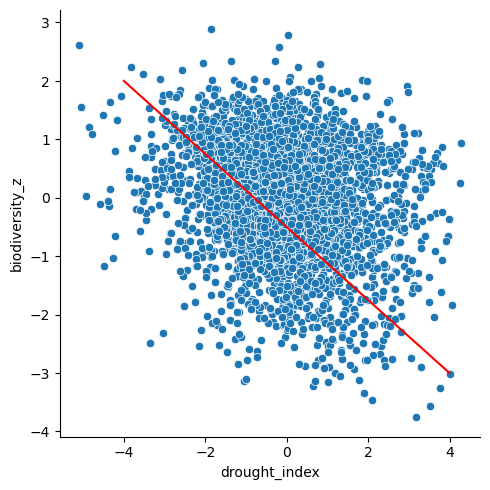

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

train_data = X_trainval.copy()
train_data['biodiversity_z'] = y_trainval

sns.relplot(data = train_data,
            kind='scatter',
            x='drought_index',
            y='biodiversity_z')
plt.plot([-4, 4], [2, -3], 'r-')
plt.show();

-Let's try biodiversity_z decreasing by 0.057 for every extra hot day per (lagged) month (-0.8/14)-  
Let's try biodiversity_z (turnover) decreasing by 0.625 for every increase in drought index by 1 (lagged) month ((4-(-4))/(-3-(2)))

In [ ]:
# intuition_pred_train = -0.057*train_data['n_hot_days_lag1']
# model_scores.append(score_model('Heuristic Model Train', y_trainval, intuition_pred_train))
# pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.64,0.82,167.92,0.000
1,Baseline Model Test,1.37,1.47,101.64,-0.060
2,Heuristic Model Train,0.64,0.82,107.35,-0.012


In [26]:
intuition_pred_train = -0.625*train_data['drought_index']
model_scores.append(score_model('Heuristic Model Train', y_trainval, intuition_pred_train))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.97,1.22,457.59,-0.446


In [ ]:
# intuition_pred_test = -0.057*X_test['n_hot_days_lag1']
# model_scores.append(score_model('Heuristic Model Test', y_test, intuition_pred_test))
# pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.64,0.82,167.92,0.000
1,Baseline Model Test,1.37,1.47,101.64,-0.060
2,Heuristic Model Train,0.64,0.82,107.35,-0.012
3,Heuristic Model Test,1.36,1.47,100.77,-0.047


In [27]:
intuition_pred_test = -0.625*X_test['drought_index']
model_scores.append(score_model('Heuristic Model Test', y_test, intuition_pred_test))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.97,1.22,457.59,-0.446
3,Heuristic Model Test,0.95,1.15,455.39,-1.228


The heuristic model performs worse than the dummy model. Let's see if we can do better with a Regression model.

---
### Create pipeline

Define branches for numeric and categorical preprocessing for each model in model selection step (below)

Distance-based models (e.g. KNN) needs scaled features but Tree-based models don't

In [29]:
cat_features = ['state']
cyc_features = ['month_sin', 'month_cos']
num_features = [col for col in X_test.columns if (col not in (cat_features + cyc_features)) and col != 'year_offset']

In [30]:
# Build categorical pipeline (with one-hot-encoding for state)
oh_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Create preprocessor for model (xgboost doesn't need scaled features)

In [31]:
preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features),
        ('cyc', 'passthrough', cyc_features)
    ]
)

preprocessor_noscale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Build full pipeline:  

In [32]:
# XGBoost
full_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('model', XGBRegressor())
])


---
Model selection and fine tuning

define model & grid

In [ ]:
# models = {
#     'XGBoost': {
#         'pipeline': full_pipeline_xgb,
#         'param_grid': {
#             'model__n_estimators': [100, 300, 500],
#             'model__max_depth': [3, 5, 7],
#             "model__min_child_weight": [1, 3, 5],
#             'model__learning_rate': [0.01, 0.05, 0.1],
#             'model__subsample': [0.7, 1.0],
#             'model__colsample_bytree': [0.7, 1.0]
#         }
#     }
# }

---
Use manual time-aware train-val split

In [33]:
# Helper function for expanding splits
def get_expanding_splits(years, min_train_years=5):
    splits = []
    
    for i in range(min_train_years, len(years)):
        train_years = years[:i]
        val_year = years[i]
        splits.append((train_years, val_year))
    
    return splits

Apply function

Let's try using Bayesian optimisation (Optuna), which intelligently searches the space instead of trying everything, with early stopping.  

Note: Early stopping only works for some models (in this case, only XGBoost, not KNN or RF)

In [34]:
import optuna
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import mean_squared_error

def optuna_rolling_search_regression(
    df,
    features,
    target,
    pipeline,
    param_space_fn,
    min_train_years=10,
    n_trials=50,
    use_early_stopping=False,
    early_stopping_rounds=50
):
    """
    Rolling CV Optuna search for regression models (e.g. XGBoost Regressor)
    """

    # 1️⃣ Prepare rolling splits
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)

    def objective(trial):
        # 2️⃣ Sample hyperparameters
        params = param_space_fn(trial)

        fold_scores = []

        for train_years, val_year in splits:
            train = df[df['year_offset'].isin(train_years)]
            val   = df[df['year_offset'] == val_year]

            X_train, y_train = train[features], train[target]
            X_val, y_val     = val[features], val[target]

            # 3️⃣ Clone pipeline
            pipe = clone(pipeline)
            pipe.set_params(**params)

            # 4️⃣ Early stopping (only works if final model supports it)
            fit_params = {}
            if use_early_stopping:
                fit_params = {
                    'model__eval_set': [(X_val, y_val)],
                    'model__early_stopping_rounds': early_stopping_rounds,
                    'model__verbose': False
                }

            pipe.fit(X_train, y_train, **fit_params)

            # 5️⃣ Predict (REGRESSION)
            y_pred = pipe.predict(X_val)

            # 6️⃣ Metric (RMSE)
            rmse = root_mean_squared_error(y_val, y_pred)
            fold_scores.append(rmse)

        # 7️⃣ Return mean score across folds
        return np.mean(fold_scores)

    # 8️⃣ Run study (minimize RMSE)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    # 9️⃣ Collect results
    results = []
    for trial in study.trials:
        results.append({
            'params': trial.params,
            'rmse': trial.value,
        })

    results_df = pd.DataFrame(results).sort_values('rmse')

    return study, results_df

c:\Users\Darach\miniconda3\envs\wildsignal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
def xgb_param_space(trial):
    return {
        # 🌳 Tree structure
        "model__max_depth": trial.suggest_int("max_depth", 3, 10),
        "model__min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        # 🎯 Learning
        "model__learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "model__n_estimators": trial.suggest_int("n_estimators", 200, 1500),

        # 🌲 Sampling
        "model__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # ⚖️ Regularization
        "model__gamma": trial.suggest_float("gamma", 0, 5),
        "model__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "model__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
    }


In [39]:
features = cat_features + cyc_features + num_features

study, results_df = optuna_rolling_search_regression(
    df=train_val,
    features=features,
    target='biodiversity_z',
    # target='n_species',
    pipeline=full_pipeline_xgb,
    param_space_fn=xgb_param_space,
    n_trials=50,
    use_early_stopping=False
)

[I 2026-04-19 23:36:41,354] A new study created in memory with name: no-name-fa2a7512-8259-45f2-b5e7-0d0631617d76
[I 2026-04-19 23:36:50,687] Trial 0 finished with value: 1.1545944624717686 and parameters: {'max_depth': 9, 'min_child_weight': 3, 'learning_rate': 0.011804516407118774, 'n_estimators': 668, 'subsample': 0.8318575806225795, 'colsample_bytree': 0.7252400832255452, 'gamma': 0.29916177991784865, 'reg_alpha': 7.2978452674517e-08, 'reg_lambda': 1.554480758843403e-08}. Best is trial 0 with value: 1.1545944624717686.
[I 2026-04-19 23:36:52,356] Trial 1 finished with value: 1.1252794890704496 and parameters: {'max_depth': 5, 'min_child_weight': 3, 'learning_rate': 0.022008853410012328, 'n_estimators': 216, 'subsample': 0.7437653178075396, 'colsample_bytree': 0.8663035742236813, 'gamma': 3.244394469432045, 'reg_alpha': 0.059343787556795945, 'reg_lambda': 4.873031979613176}. Best is trial 1 with value: 1.1252794890704496.
[I 2026-04-19 23:36:58,616] Trial 2 finished with value: 1.09

In [40]:
# Sort by F1
results_df.sort_values('rmse', ascending=True).head(10)

,params,rmse
43,"{'max_depth': 3, 'min_child_weight': 2, 'learn...",1.066717
42,"{'max_depth': 4, 'min_child_weight': 2, 'learn...",1.069745
47,"{'max_depth': 3, 'min_child_weight': 2, 'learn...",1.070193
46,"{'max_depth': 3, 'min_child_weight': 2, 'learn...",1.070323
48,"{'max_depth': 3, 'min_child_weight': 3, 'learn...",1.071033
45,"{'max_depth': 3, 'min_child_weight': 3, 'learn...",1.071095
44,"{'max_depth': 3, 'min_child_weight': 2, 'learn...",1.071486
35,"{'max_depth': 5, 'min_child_weight': 1, 'learn...",1.072222
34,"{'max_depth': 6, 'min_child_weight': 1, 'learn...",1.074022
49,"{'max_depth': 4, 'min_child_weight': 2, 'learn...",1.074528


In [41]:
# Best trial according to Optuna
best_trial = study.best_trial

print("Best rmse:", best_trial.value)
print("Best parameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best rmse: 1.0667165113708699
Best parameters:
  max_depth: 3
  min_child_weight: 2
  learning_rate: 0.001427402905594898
  n_estimators: 359
  subsample: 0.886167480558406
  colsample_bytree: 0.6040601848326436
  gamma: 4.438252576937204
  reg_alpha: 6.122794242326978e-07
  reg_lambda: 8.821145195069854e-07


Visualise results

C:\Users\Darach\AppData\Local\Temp\ipykernel_23404\2474202550.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study);


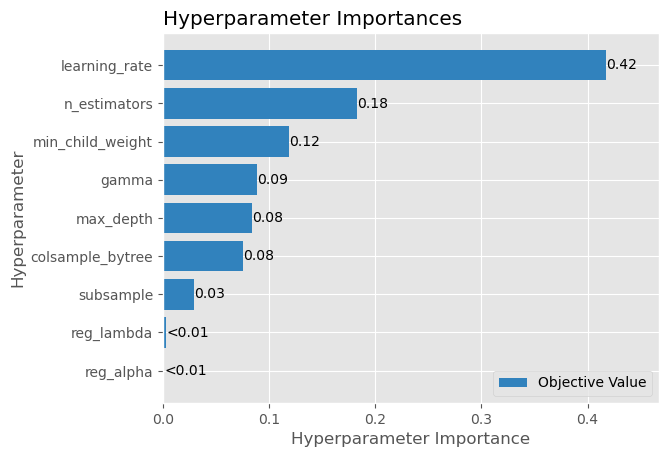

In [42]:
# Parameter importance
optuna.visualization.matplotlib.plot_param_importances(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_23404\2656397370.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study);


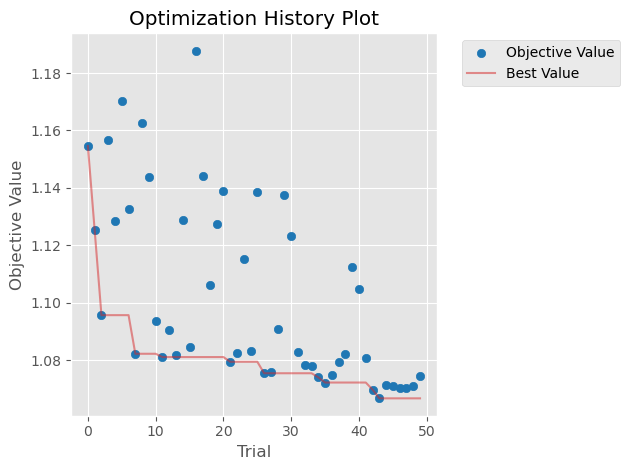

In [43]:
# Optimization history (how F1 improved over trials)
optuna.visualization.matplotlib.plot_optimization_history(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_23404\2949398106.py:2: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Axes: title={'center': 'Parallel Coordinate Plot'}>

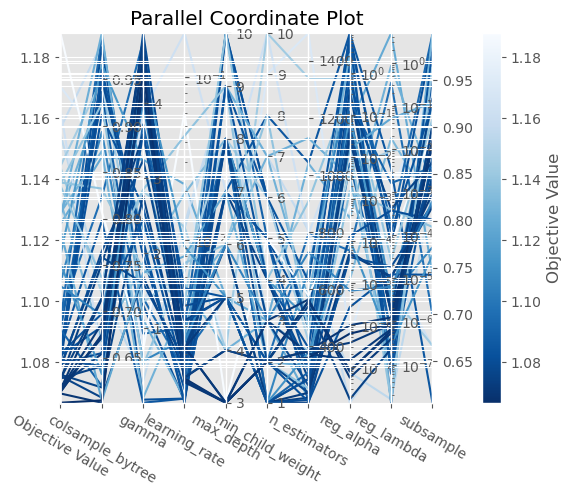

In [44]:
# Parallel coordinate plot (show trade-offs between params and F1)
optuna.visualization.matplotlib.plot_parallel_coordinate(study)

Use best parameters for training on full training data

In [45]:
best_params = {f"model__{k}": v for k, v in best_trial.params.items()}

# Set these in your pipeline
full_pipeline_xgb.set_params(**best_params)

# Fit the pipeline on full training data
full_pipeline_xgb.fit(X_trainval, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Evaluate

In [46]:
# Predict probabilities on training set
train_preds = full_pipeline_xgb.predict(X_trainval)
model_scores.append(score_model('XGB Train', y_trainval, train_preds))

# Predict probabilities on test set
test_preds = full_pipeline_xgb.predict(X_test)
model_scores.append(score_model('XGB Test', y_test, test_preds))

In [47]:
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.97,1.22,457.59,-0.446
3,Heuristic Model Test,0.95,1.15,455.39,-1.228
4,XGB Train,0.78,0.98,121.94,0.068
5,XGB Test,0.68,0.82,125.82,-0.132


---
Train R-squared is quite high and test R-squared is much lower - perhaps overfitting?  
Experiment - can we do better with reduced feature set?

In [48]:
# reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
#  'n_hot_days_lag1', 'n_hot_days_roll3',
#  'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#  'temp_anom_z_lag1', 'temp_anom_z_roll3',
#  'precip_anom_z_lag1', 'precip_anom_z_roll3',
#  'drought_index_lag1','drought_index_roll3', 
#  'log_n_obs', 'biodiversity_z']

reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_roll3','temp_anom_z_lag1', 'drought_index_roll3', 
    'biodiversity_z', 'temp_anom_z_sq', 'drought_index_sq', 
    'int1', 'int2', 'int3']

trainval_reduced = train_val[reduced_cols].copy()
trainval_reduced.columns

Index(['state', 'year_offset', 'month_sin', 'month_cos', 'n_hot_days_roll3',
       'temp_anom_z_lag1', 'drought_index_roll3', 'biodiversity_z',
       'temp_anom_z_sq', 'drought_index_sq', 'int1', 'int2', 'int3'],
      dtype='object')

In [49]:
num_features_reduced = [c for c in num_features if c in reduced_cols and c != 'year_offset']
num_features_reduced

['n_hot_days_roll3',
 'temp_anom_z_lag1',
 'drought_index_roll3',
 'temp_anom_z_sq',
 'drought_index_sq',
 'int1',
 'int2',
 'int3']

In [50]:
# Create reduced-features pipeline

preprocessor_noscale_reduced = ColumnTransformer(    transformers=[
        #('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features_reduced),
        #('cyc', 'passthrough', cyc_features)
    ])


# Rebuild your pipeline with the updated preprocessor

full_pipeline_xgb_reduced = Pipeline([
    ('pre', preprocessor_noscale_reduced),
    ('model', XGBRegressor())
])

In [52]:
# features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
#     'n_hot_days_lag1', 'n_hot_days_roll3',
#     'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#     'temp_anom_z_lag1', 'temp_anom_z_roll3',
#     'precip_anom_z_lag1', 'precip_anom_z_roll3',
#     'drought_index_lag1', 'drought_index_roll3', 
#     'log_n_obs']

# features_reduced = [
#     'n_hot_days_roll3',
#     'heavy_rain_days_roll3',
#     'temp_anom_z', 'temp_anom_z_lag1', 
#     'precip_anom_z', 'precip_anom_z_roll3',
#     'drought_index', 'drought_index_roll3', 'temp_anom_z_sq', 'drought_index_sq', 'precip_anom_z_sq']

features_reduced = num_features_reduced

study_reduced, results_df_reduced = optuna_rolling_search_regression(
    df=trainval_reduced,
    features=features_reduced,
    target='biodiversity_z',
    pipeline=full_pipeline_xgb_reduced,
    param_space_fn=xgb_param_space,
    n_trials=50
)

[I 2026-04-19 23:42:48,972] A new study created in memory with name: no-name-07c2493c-072d-48e2-849b-8c9bab462853
[I 2026-04-19 23:42:57,666] Trial 0 finished with value: 1.0860316227281583 and parameters: {'max_depth': 8, 'min_child_weight': 4, 'learning_rate': 0.0010603430895402737, 'n_estimators': 911, 'subsample': 0.8577689456365682, 'colsample_bytree': 0.8553855729473424, 'gamma': 1.5516334338550897, 'reg_alpha': 1.3920601024845165e-05, 'reg_lambda': 2.003175669743337e-08}. Best is trial 0 with value: 1.0860316227281583.
[I 2026-04-19 23:43:01,908] Trial 1 finished with value: 1.088609227813302 and parameters: {'max_depth': 8, 'min_child_weight': 10, 'learning_rate': 0.003133728057324846, 'n_estimators': 350, 'subsample': 0.7870544203921684, 'colsample_bytree': 0.716832723172713, 'gamma': 1.3516218237735245, 'reg_alpha': 1.748233713519998e-08, 'reg_lambda': 5.979606384182324e-07}. Best is trial 0 with value: 1.0860316227281583.
[I 2026-04-19 23:43:05,716] Trial 2 finished with val

In [53]:
# Sort by F1
results_df_reduced.sort_values('rmse', ascending=True).head(10)

,params,rmse
43,"{'max_depth': 7, 'min_child_weight': 8, 'learn...",1.069167
45,"{'max_depth': 7, 'min_child_weight': 9, 'learn...",1.069434
11,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070058
41,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070155
33,"{'max_depth': 8, 'min_child_weight': 7, 'learn...",1.070161
49,"{'max_depth': 8, 'min_child_weight': 8, 'learn...",1.070225
12,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070443
10,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070578
31,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070766
21,"{'max_depth': 6, 'min_child_weight': 7, 'learn...",1.070850


In [54]:
# Best trial according to Optuna
best_trial_reduced = study_reduced.best_trial

print("Best AUC:", best_trial_reduced.value)
# print("Best threshold_f1:", best_trial_reduced.user_attrs.get('best_threshold_f1', None))
# print("Best threshold_recall:", best_trial_reduced.user_attrs.get('best_threshold_recall', None))
print("Best parameters:")
for key, value in best_trial_reduced.params.items():
    print(f"  {key}: {value}")

Best AUC: 1.0691668230048177
Best parameters:
  max_depth: 7
  min_child_weight: 8
  learning_rate: 0.0010241923528349465
  n_estimators: 200
  subsample: 0.6798071458518996
  colsample_bytree: 0.9572769377036273
  gamma: 2.1895710885538664
  reg_alpha: 9.469090699049387
  reg_lambda: 2.1126288494957017


Use best parameters for training on full training data with best threshold

In [55]:
best_params_reduced = best_trial_reduced.params
best_params_prefixed = {f"model__{k}": v for k, v in best_params_reduced.items()}

# Set these in pipeline
full_pipeline_xgb_reduced.set_params(**best_params_prefixed)

# Fit the pipeline on full training data
X_trainval_reduced = X_trainval[features_reduced]
full_pipeline_xgb_reduced.fit(X_trainval_reduced, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,

Evaluate

In [56]:
# Predict probabilities on training set
train_preds_reduced = full_pipeline_xgb_reduced.predict(X_trainval_reduced)
model_scores.append(score_model('XGB reduced Train', y_trainval, train_preds_reduced))

# Predict probabilities on test set
X_test_reduced = X_test[features_reduced]
test_preds_reduced = full_pipeline_xgb_reduced.predict(X_test_reduced)
model_scores.append(score_model('XGB reduced Test', y_test, test_preds_reduced))

In [57]:
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.97,1.22,457.59,-0.446
3,Heuristic Model Test,0.95,1.15,455.39,-1.228
4,XGB Train,0.78,0.98,121.94,0.068
5,XGB Test,0.68,0.82,125.82,-0.132
6,XGB reduced Train,0.80,1.00,129.76,0.029
7,XGB reduced Test,0.67,0.82,111.51,-0.115


Slightly better with the reduced feature set

---
Train production model using all data (train and test together) with best params

In [363]:
# clone the pipeline as a production model
pipeline_production = clone(full_pipeline_xgb_reduced)
pipeline_production.set_params(**best_params_prefixed)

# Fit the production pipeline on full data
X_full_reduced = df[features_reduced].copy()
y_full = df['n_species']
pipeline_production.fit(X_full_reduced, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,

In [364]:
# sanity check
X_test_reduced = X_test[features_reduced]
y_pred = pipeline_production.predict(X_full_reduced)

print(r2_score(y_full, y_pred))

0.29059884662415125


save evaluation model and production model

In [365]:
import joblib

joblib.dump({
    "model": full_pipeline_xgb_reduced,
    "features": features_reduced
}, "../models/evaluation_model_regression_climateonly.pkl")

joblib.dump({
    "model": pipeline_production,
    "features": features_reduced
}, "../models/production_model_regression_climateonly.pkl")

['../models/production_model_regression_climateonly.pkl']

---
diagnostics

In [58]:
model = full_pipeline_xgb_reduced.named_steps["model"]

pd.DataFrame({
    'feature': model.feature_names_in_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

,feature,importance
2,num__drought_index_roll3,0.192550
0,num__n_hot_days_roll3,0.143355
6,num__int2,0.131844
7,num__int3,0.120680
1,num__temp_anom_z_lag1,0.112198
5,num__int1,0.107137
4,num__drought_index_sq,0.106253
3,num__temp_anom_z_sq,0.085983
